# Parte B: Bifurcación en el modelo térmico

La ecuación diferencial ordinaria (EDO) dada es:

$$\frac{du}{dt} = μ\,u + u^{3}$$

donde \(u(t)\) es la temperatura adimensional (desviación respecto al ambiente) y \(μ\) es un parámetro.

## 1. Puntos de equilibrio en función de \(μ\)

Los puntos de equilibrio se encuentran igualando la derivada a cero:

$$μ\,u + u^{3} = 0.$$

Factorizando:

$$u(μ + u^{2}) = 0.$$

Las soluciones son:

- \(u = 0\) para todo \(μ\).
- \(μ + u^{2} = 0 \Rightarrow u^{2} = -μ \Rightarrow u = \pm\sqrt{-μ}\), que solo existen para \(μ \le 0\).

Por lo tanto, los puntos de equilibrio son:

- \(u = 0\) para todo \(μ\).
- \(u = \pm\sqrt{-μ}\) para \(μ < 0\) (en \(μ = 0\) estas ramas se colapsan en \(u=0\)).

## 2. Clasificación de la estabilidad

Definimos \(f(u)=μ\,u + u^{3}\). Su derivada es:

$$f'(u)=μ + 3u^{2}.$$

Evaluamos \(f'(u)\) en cada punto de equilibrio:

- Para \(u = 0\):

  $$f'(0) = μ.$$

  - Si \(μ > 0\), \(f'(0)>0\) ⇒ \(u=0\) es inestable.
  - Si \(μ < 0\), \(f'(0)<0\) ⇒ \(u=0\) es estable.
  - Si \(μ = 0\), \(f'(0)=0\) y el análisis lineal no es suficiente. Mediante análisis no lineal (la EDO se reduce a \(\frac{du}{dt}=u^{3}\)): para \(u>0\), \(\frac{du}{dt}>0\) y para \(u<0\), \(\frac{du}{dt}<0\), por lo que \(u=0\) es inestable (es una fuente no lineal).

- Para \(u = \pm\sqrt{-μ}\) (cuando \(μ<0\)):

  Sustituyendo \(u^{2} = -μ\):

  $$f\big(\pm\sqrt{-μ}\big)' = μ + 3(-μ) = μ - 3μ = -2μ.$$

  Como \(μ < 0\), se tiene \(-2μ > 0\), por lo tanto ambos puntos \(u=\pm\sqrt{-μ}\) son inestables.


## 3. Diagrama de bifurcacion

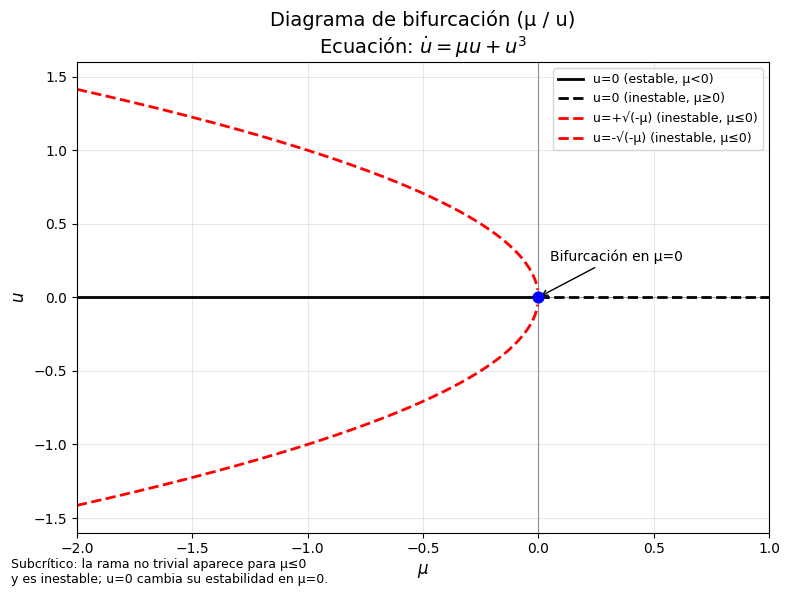

In [14]:

import numpy as np
import matplotlib.pyplot as plt

# rango de mu y resolución
mu_min, mu_max = -2.0, 1.0
N = 800
mu = np.linspace(mu_min, mu_max, N)

# rama trivial u = 0 (vamos a trazarla con distinto estilo según estabilidad)
u_zero = np.zeros_like(mu)
stable_mask = mu < 0
unstable_mask = mu >= 0

# ramas no triviales: u = ±sqrt(-mu) solo para mu <= 0
mask_nontriv = mu <= 0
mu_nontriv = mu[mask_nontriv]
u_pos = np.sqrt(-mu_nontriv)
u_neg = -u_pos

# Preparar figura
plt.figure(figsize=(8, 6))
plt.title("Diagrama de bifurcación (μ / u)\nEcuación: $\\dot u = μ u + u^{3}$", fontsize=14)

# dibujar ramas
# rama trivial: estable (μ<0) como línea continua negra, inestable (μ>=0) como línea discontinua negra
plt.plot(mu[stable_mask], u_zero[stable_mask], 'k-', lw=2, label='u=0 (estable, μ<0)')
plt.plot(mu[unstable_mask], u_zero[unstable_mask], 'k--', lw=2, label='u=0 (inestable, μ≥0)')

# ramas no triviales (inestables para μ<0): usar línea roja discontinua
plt.plot(mu_nontriv, u_pos, 'r--', lw=2, label='u=+√(-μ) (inestable, μ≤0)')
plt.plot(mu_nontriv, u_neg, 'r--', lw=2, label='u=-√(-μ) (inestable, μ≤0)')

# marcar el punto de bifurcación (μ=0, u=0)
plt.scatter([0.0], [0.0], c='blue', s=60, zorder=5)
plt.annotate('Bifurcación en μ=0', xy=(0.0, 0.0), xytext=(0.05, 0.25),
             arrowprops=dict(arrowstyle='->', lw=1.0), fontsize=10)

# mejorar estética
plt.xlabel(r'$\mu$', fontsize=12)
plt.ylabel(r'$u$', fontsize=12)
plt.axvline(0, color='gray', lw=0.8, zorder=0)
plt.axhline(0, color='gray', lw=0.6, zorder=0)
plt.xlim(mu_min, mu_max)
plt.ylim(-1.6, 1.6)
plt.grid(alpha=0.3)
plt.legend(loc='upper right', fontsize=9)

# Añadir una pequeña explicación en la figura
texto = ("Subcrítico: la rama no trivial aparece para μ≤0\n"
         "y es inestable; u=0 cambia su estabilidad en μ=0.")
plt.gcf().text(0.02, 0.02, texto, fontsize=9)

# guardar y mostrar
plt.tight_layout()
plt.savefig("bifurcation_mu_u.png", dpi=200)
plt.show()

## Tipo de bifurcación

Tipo de bifurcación: bifurcación pitchfork subcrítica.

En μ = 0 el punto u = 0 cambia de inestable (para μ > 0) a estable (para μ < 0), y aparecen dos ramas no triviales u = ±√(−μ) que son inestables para μ < 0.